# ResNet18 Image Classification

In [ ]:
# Build the resnet18 model (https://arxiv.org/abs/1512.03385). It is your choice whether you
# design the resnet18 from scratch or download the resnet model from the torchvision. However,
# additional marks are given if the resnet18 model is created from scratch. As per question 1, use the
# cross-entropy loss function, and the SGD optimizer.

# The batch size and the learning rate are set at 32
# and 0.01 respectively. Train your model in the training set and evaluate your model in the testing set.
# Train and evaluate your model using three datasets: MNIST, CIFAR10, CIFAR100. Include
# visualization to show the predictive performance of your method.

## Section 1 — Imports and Setup


In [ ]:
# ============================================
# Imports and setup
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import random

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [ ]:
# ============================================
# Reproducibility and device
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## Section 2 — Global Visualization


In [ ]:
# ============================================
# GLOBAL VISUALIZATION
# ============================================


PALETTE = {
    "loss":          "#8E1B1B",  # deep classic red
    "accuracy":      "#1F4E79",  # navy blue
    "bar_primary":   "#2E5C6E",  # slate teal
    "bar_secondary": "#8E1B1B",
    "grid":          "#B0B0B0",
    "correct":       "#1B7837",  # forest green
    "incorrect":     "#B2182B",  # crimson
}

plt.rcParams.update({
    # Fonts — classic serif, bold headings
    "font.family":        "serif",
    "font.serif":         ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size":          13,

    # Titles & axis labels
    "axes.titlesize":     17,
    "axes.titleweight":   "bold",
    "axes.labelsize":     14,
    "axes.labelweight":   "bold",
    "figure.titlesize":   19,
    "figure.titleweight": "bold",

    # Tick labels
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # Legend
    "legend.fontsize":    12,
    "legend.frameon":     True,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#333333",

    # Axes & grid — clean, classic look
    "axes.facecolor":     "#FAFAFA",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     1.3,
    "grid.color":         PALETTE["grid"],
    "grid.linestyle":     "--",
    "grid.alpha":         0.55,
    "axes.grid":          True,

    # Figure
    "figure.facecolor":   "white",
    "figure.dpi":         110,
    "savefig.dpi":        160,
})

print("Global plot style applied: classic serif theme with bold titles/labels.")


Global plot style applied: classic serif theme with bold titles/labels.


## Section 3 — Training Configuration

In [ ]:
# ============================================
# Assignment training settings
# ============================================

BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 10

print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Optimiser: SGD")
print("Loss function: CrossEntropyLoss")


Batch size: 32
Learning rate: 0.01
Epochs: 10
Optimiser: SGD
Loss function: CrossEntropyLoss


## Section 4 — Dataset Preprocessing

In [ ]:
# ============================================
# Dataset preprocessing
# ============================================

# MNIST preprocessing
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# CIFAR preprocessing
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Load datasets
mnist_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

cifar10_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cifar_transform
)

cifar10_test = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cifar_transform
)

cifar100_train = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=cifar_transform
)

cifar100_test = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=cifar_transform
)

print("MNIST:", len(mnist_train), "train /", len(mnist_test), "test")
print("CIFAR-10:", len(cifar10_train), "train /", len(cifar10_test), "test")
print("CIFAR-100:", len(cifar100_train), "train /", len(cifar100_test), "test")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]
100%|██████████| 170M/170M [03:47<00:00, 748kB/s]
100%|██████████| 169M/169M [02:57<00:00, 954kB/s] 


MNIST: 60000 train / 10000 test
CIFAR-10: 50000 train / 10000 test
CIFAR-100: 50000 train / 10000 test


## Section 5 — Data Loaders

In [ ]:
# ============================================
# Data loaders
# ============================================

mnist_train_loader = DataLoader(
    mnist_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

mnist_test_loader = DataLoader(
    mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

cifar10_train_loader = DataLoader(
    cifar10_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

cifar10_test_loader = DataLoader(
    cifar10_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

cifar100_train_loader = DataLoader(
    cifar100_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

cifar100_test_loader = DataLoader(
    cifar100_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully.")


DataLoaders created successfully.


## Section 6 — Visualising Images

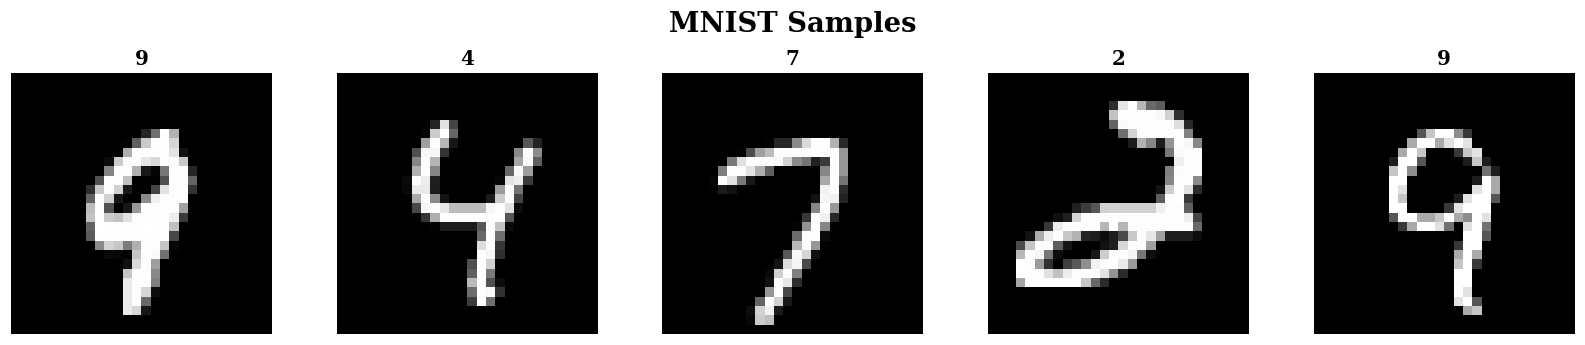

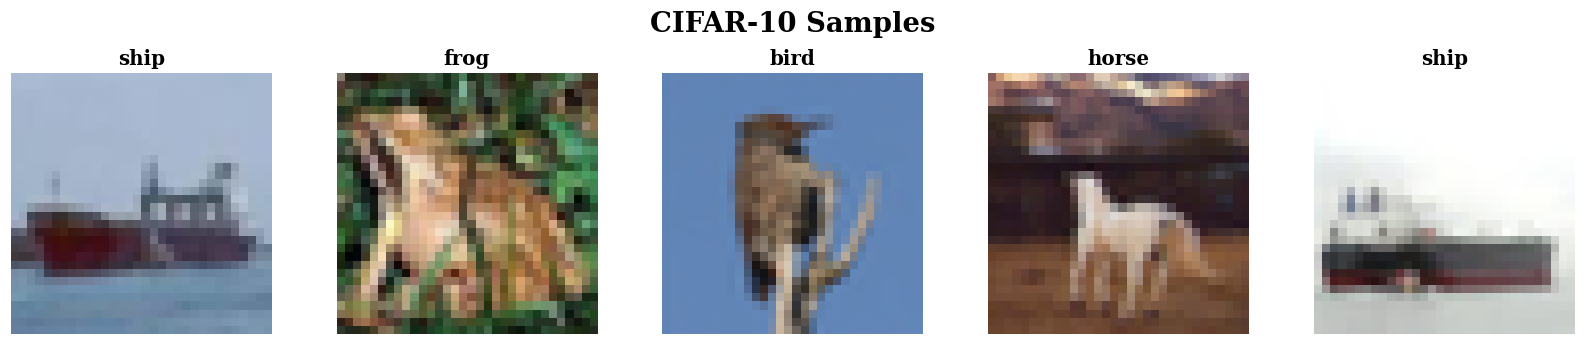

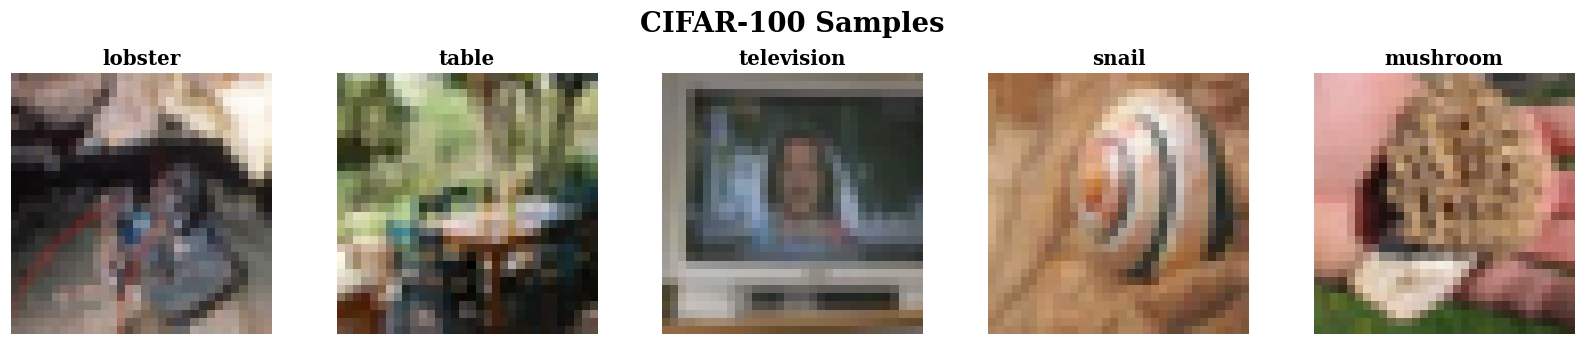

In [ ]:
# ============================================
# Dataset visualisation
# ============================================

mnist_class_names = [str(i) for i in range(10)]

cifar10_class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cifar100_class_names = cifar100_train.classes

def show_dataset_samples(dataset, class_names, title, n=5):
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(15, 3.2))
    fig.suptitle(title, fontsize=18, fontweight="bold")

    for ax, idx in zip(axes, indices):
        image, label = dataset[idx]
        image = image.clone()

        # Undo normalisation for display
        if image.shape[0] == 1:
            image = image * 0.3081 + 0.1307
            image = image.squeeze(0)
            ax.imshow(image.numpy(), cmap="gray")
        else:
            mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
            std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
            image = image * std + mean
            image = torch.clamp(image, 0, 1)
            ax.imshow(image.permute(1, 2, 0).numpy())

        ax.set_title(class_names[label], fontsize=13, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_dataset_samples(mnist_train, mnist_class_names, "MNIST Samples")
show_dataset_samples(cifar10_train, cifar10_class_names, "CIFAR-10 Samples")
show_dataset_samples(cifar100_train, cifar100_class_names, "CIFAR-100 Samples")


## Section 7 — ResNet18 Architecture From Scratch

In [ ]:
# ResNet18 uses residual/skip connections. A residual block learns a residual function and adds the original input to the transformed output.

# The implementation below follows the ResNet18 structure:
# - initial convolution
# - four convolutional stages
# - two residual blocks per stage
# - adaptive average pooling
# - fully connected classification layer

# For small 28×28 and 32×32 images, a CIFAR-style 3×3 initial convolution is used instead of the original ImageNet 7×7 convolution and large max-pooling operation.

In [ ]:
# ============================================
# ResNet18 from scratch
# ============================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Identity shortcut when dimensions are unchanged.
        # Projection shortcut is used when channels/spatial size change.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18Scratch(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18Scratch, self).__init__()

        self.in_channels = 64

        # CIFAR/small-image friendly stem
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # ResNet18: [2, 2, 2, 2] BasicBlocks
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = [
            BasicBlock(self.in_channels, out_channels, stride)
        ]

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(self.in_channels, out_channels, stride=1)
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_check = ResNet18Scratch(num_classes=10)
print(model_check)
print("\nTrainable parameters:", f"{count_parameters(model_check):,}")


ResNet18Scratch(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), st

## Section 8 — Preparing MNIST for ResNet18.

In [ ]:
# MNIST is grayscale, so each image is converted to three identical channels. This allows the same ResNet18 input
# structure to be used for all three datasets

In [ ]:
# ============================================
# Convert MNIST from 1 channel to 3 channels
# ============================================

mnist_resnet_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307, 0.1307, 0.1307),
        (0.3081, 0.3081, 0.3081)
    )
])

mnist_resnet_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_resnet_transform
)

mnist_resnet_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_resnet_transform
)

mnist_resnet_train_loader = DataLoader(
    mnist_resnet_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

mnist_resnet_test_loader = DataLoader(
    mnist_resnet_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available()
)

sample_x, sample_y = mnist_resnet_train[0]
print("MNIST sample shape after conversion:", sample_x.shape)
print("Label:", sample_y)


MNIST sample shape after conversion: torch.Size([3, 28, 28])
Label: 5


## Section 9 — ResNet18 Training Function


In [ ]:
# CrossEntropyLoss is used directly with the model's raw logits. A separate Softmax operation is not added to the model because
# PyTorch's CrossEntropyLoss internally combines the required log-softmax and negative log-likelihood operations.

In [ ]:
# ============================================
# Training function
# ============================================

def train_resnet_model(model, train_loader, epochs=EPOCHS):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

    losses = []
    accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total

        losses.append(epoch_loss)
        accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    return model, losses, accuracies, training_time


## Section 10 — ResNet18 Evaluation Function

In [ ]:
# ============================================
# Evaluation function
# ============================================

def evaluate_resnet_model(model, test_loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions) * 100
    precision = precision_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    ) * 100
    recall = recall_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    ) * 100
    f1 = f1_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    ) * 100

    cm = confusion_matrix(all_labels, all_predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }


## Section 11 — Training Visualisation Functions

In [ ]:
# ============================================
# Training visualisations
# ============================================

def plot_resnet_training_history(losses, accuracies, dataset_name):

    epochs = range(1, len(losses) + 1)

    # ----------------------------------------
    # 1. TRAINING LOSS
    # ----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs, losses,
        marker="o", linewidth=2.5, markersize=8,
        color=PALETTE["loss"], markerfacecolor="white",
        markeredgewidth=2, markeredgecolor=PALETTE["loss"],
    )
    plt.fill_between(epochs, losses, alpha=0.12, color=PALETTE["loss"])

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(f"{dataset_name} — ResNet18 Training Loss", pad=14)
    plt.xticks(list(epochs))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # 2. TRAINING ACCURACY
    # ----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs, accuracies,
        marker="o", linewidth=2.5, markersize=8,
        color=PALETTE["accuracy"], markerfacecolor="white",
        markeredgewidth=2, markeredgecolor=PALETTE["accuracy"],
    )
    plt.fill_between(epochs, accuracies, alpha=0.12, color=PALETTE["accuracy"])

    plt.xlabel("Epoch")
    plt.ylabel("Training Accuracy (%)")
    plt.title(f"{dataset_name} — ResNet18 Training Accuracy", pad=14)
    plt.xticks(list(epochs))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # 3. LOSS AND ACCURACY TOGETHER (DUAL AXIS)
    # ----------------------------------------
    fig, ax1 = plt.subplots(figsize=(9, 5))

    line1, = ax1.plot(
        epochs, losses,
        marker="o", linewidth=2.5, markersize=7,
        color=PALETTE["loss"], label="Loss",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color=PALETTE["loss"], fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=PALETTE["loss"])

    ax2 = ax1.twinx()
    line2, = ax2.plot(
        epochs, accuracies,
        marker="s", linewidth=2.5, markersize=7,
        color=PALETTE["accuracy"], label="Accuracy",
    )
    ax2.set_ylabel("Accuracy (%)", color=PALETTE["accuracy"], fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=PALETTE["accuracy"])
    ax2.grid(False)

    ax1.set_xticks(list(epochs))
    ax1.legend(handles=[line1, line2], loc="center right")

    plt.title(f"{dataset_name} — Loss and Accuracy", pad=14)
    fig.tight_layout()
    plt.show()

    # ----------------------------------------
    # 4. ACCURACY IMPROVEMENT PER EPOCH
    # ----------------------------------------
    accuracy_improvement = [
        accuracies[i] - accuracies[i - 1]
        for i in range(1, len(accuracies))
    ]

    plt.figure(figsize=(8, 5))

    bar_colors = [PALETTE["correct"] if v >= 0 else PALETTE["incorrect"] for v in accuracy_improvement]

    bars = plt.bar(
        range(2, len(accuracies) + 1), accuracy_improvement,
        color=bar_colors, edgecolor="black", linewidth=0.8,
    )

    for bar, value in zip(bars, accuracy_improvement):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.1f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10, fontweight="bold",
        )

    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy Improvement (%)")
    plt.title(f"{dataset_name} — Accuracy Improvement Per Epoch", pad=14)
    plt.xticks(range(2, len(accuracies) + 1))
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # 5. LOSS REDUCTION PER EPOCH
    # ----------------------------------------
    loss_reduction = [
        losses[i - 1] - losses[i]
        for i in range(1, len(losses))
    ]

    plt.figure(figsize=(8, 5))

    bar_colors = [PALETTE["correct"] if v >= 0 else PALETTE["incorrect"] for v in loss_reduction]

    bars = plt.bar(
        range(2, len(losses) + 1), loss_reduction,
        color=bar_colors, edgecolor="black", linewidth=0.8,
    )

    for bar, value in zip(bars, loss_reduction):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.3f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10, fontweight="bold",
        )

    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Loss Reduction")
    plt.title(f"{dataset_name} — Loss Reduction Per Epoch", pad=14)
    plt.xticks(range(2, len(losses) + 1))
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, dataset_name):

    n_classes = len(class_names)

    if n_classes <= 20:
        fig_size = (10, 8)
        show_values = True
        tick_fontsize = 11
    else:
        fig_size = (18, 16)
        show_values = False
        tick_fontsize = 7

    fig, ax = plt.subplots(figsize=fig_size)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format="d" if show_values else None,
        include_values=show_values,
        colorbar=True,
    )

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=tick_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)

    ax.set_title(
        f"{dataset_name} — ResNet18 Confusion Matrix",
        fontsize=17, fontweight="bold", pad=16,
    )
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")

    plt.tight_layout()
    plt.show()


## Section 12 — Random Test Predictions

In [ ]:
# ============================================
# Random prediction visualisation
# ============================================

def show_random_predictions(model, dataset, class_names, dataset_name, n=5):
    model.eval()

    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(18, 4))
    fig.suptitle(f"{dataset_name} — Random ResNet18 Predictions", fontsize=18, fontweight="bold")

    for ax, idx in zip(axes, indices):
        image, true_label = dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        predicted_label = predicted.item()
        confidence_value = confidence.item() * 100

        is_correct = predicted_label == true_label
        result_color = PALETTE["correct"] if is_correct else PALETTE["incorrect"]

        display_image = image.clone()

        if display_image.shape[0] == 1:
            display_image = display_image * 0.3081 + 0.1307
            display_image = display_image.squeeze(0)
            ax.imshow(display_image.cpu().numpy(), cmap="gray")
        else:
            mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
            std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
            display_image = display_image * std + mean
            display_image = torch.clamp(display_image, 0, 1)
            ax.imshow(display_image.permute(1, 2, 0).cpu().numpy())

        ax.set_title(
            f"Actual: {class_names[true_label]}\n"
            f"Pred: {class_names[predicted_label]}\n"
            f"Confidence: {confidence_value:.1f}%",
            fontsize=11, fontweight="bold", color=result_color,
        )
        ax.axis("off")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(result_color)
            spine.set_linewidth(4)

    plt.tight_layout()
    plt.show()


## Section 13 — ResNet18 on MNIST

### MNIST — Training

In [ ]:
# ============================================
# Train ResNet18 on MNIST
# ============================================

mnist_resnet = ResNet18Scratch(num_classes=10)

print("MNIST ResNet18 parameters:", f"{count_parameters(mnist_resnet):,}")

mnist_resnet, mnist_losses, mnist_accuracies, mnist_training_time = train_resnet_model(
    mnist_resnet,
    mnist_resnet_train_loader
)

print(f"\nMNIST training time: {mnist_training_time:.2f} seconds")


MNIST ResNet18 parameters: 11,173,962
Epoch [1/10] Loss: 0.1215 Accuracy: 96.67%
Epoch [2/10] Loss: 0.0286 Accuracy: 99.17%
Epoch [3/10] Loss: 0.0164 Accuracy: 99.53%
Epoch [4/10] Loss: 0.0096 Accuracy: 99.74%
Epoch [5/10] Loss: 0.0063 Accuracy: 99.85%
Epoch [6/10] Loss: 0.0033 Accuracy: 99.95%
Epoch [7/10] Loss: 0.0023 Accuracy: 99.96%
Epoch [8/10] Loss: 0.0016 Accuracy: 99.98%
Epoch [9/10] Loss: 0.0016 Accuracy: 99.98%
Epoch [10/10] Loss: 0.0007 Accuracy: 100.00%

MNIST training time: 572.10 seconds


### MNIST — Evaluation

In [ ]:
# ============================================
# Evaluate MNIST ResNet18
# ============================================

mnist_results = evaluate_resnet_model(
    mnist_resnet,
    mnist_resnet_test_loader
)

print(f"Accuracy : {mnist_results['accuracy']:.2f}%")
print(f"Precision: {mnist_results['precision']:.2f}%")
print(f"Recall   : {mnist_results['recall']:.2f}%")
print(f"F1-score : {mnist_results['f1']:.2f}%")


Accuracy : 99.57%
Precision: 99.57%
Recall   : 99.57%
F1-score : 99.57%


### MNIST — Visualizations

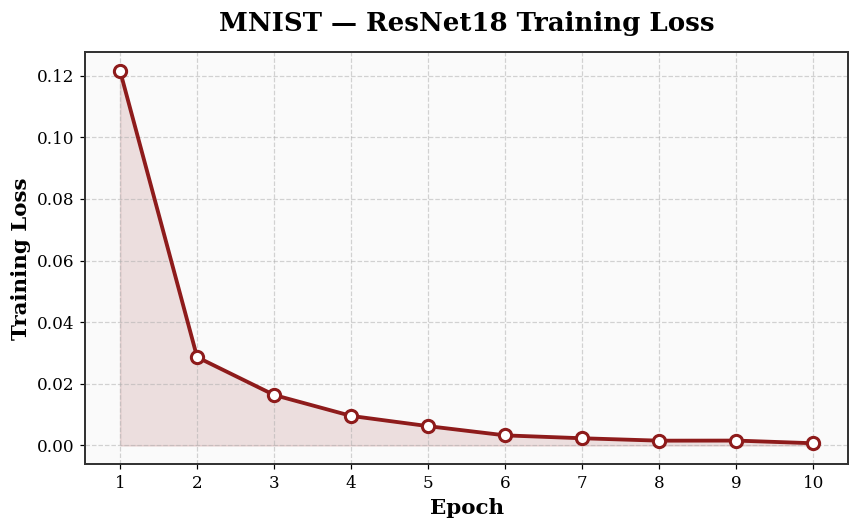

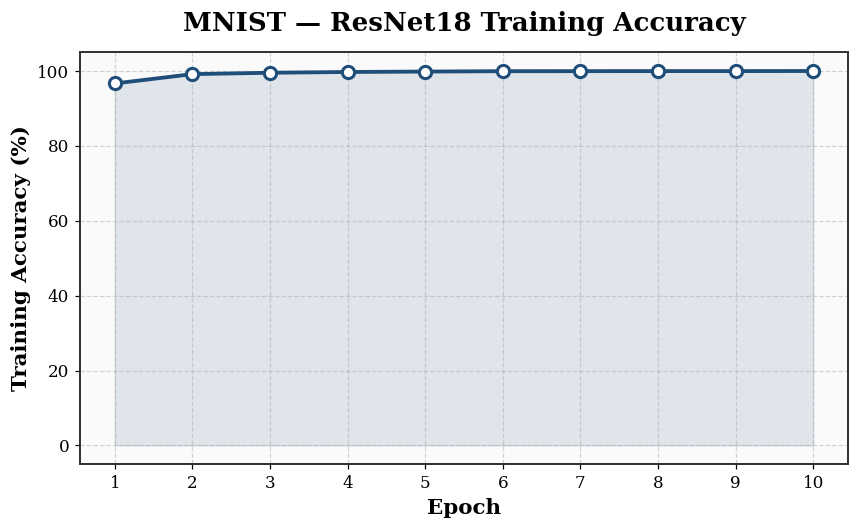

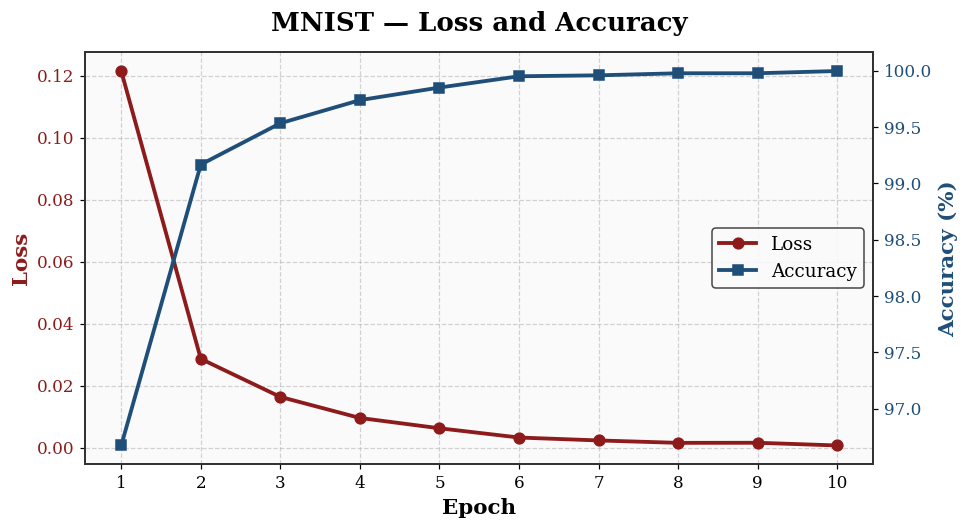

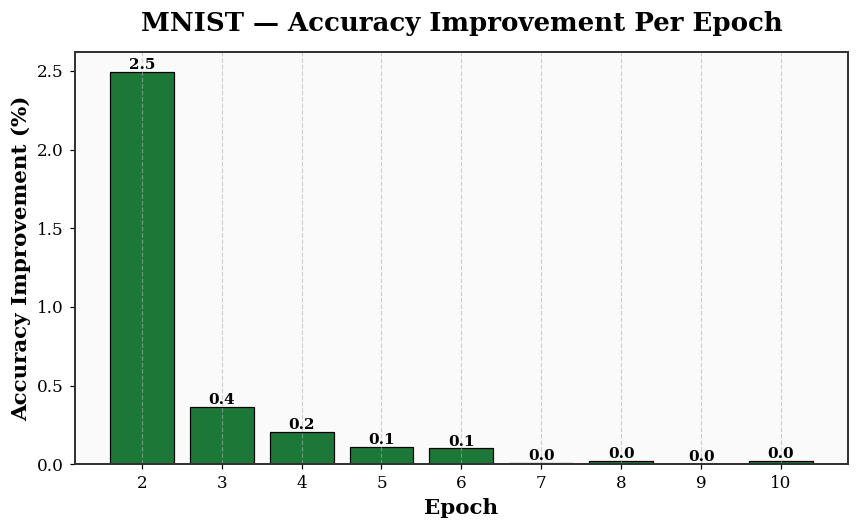

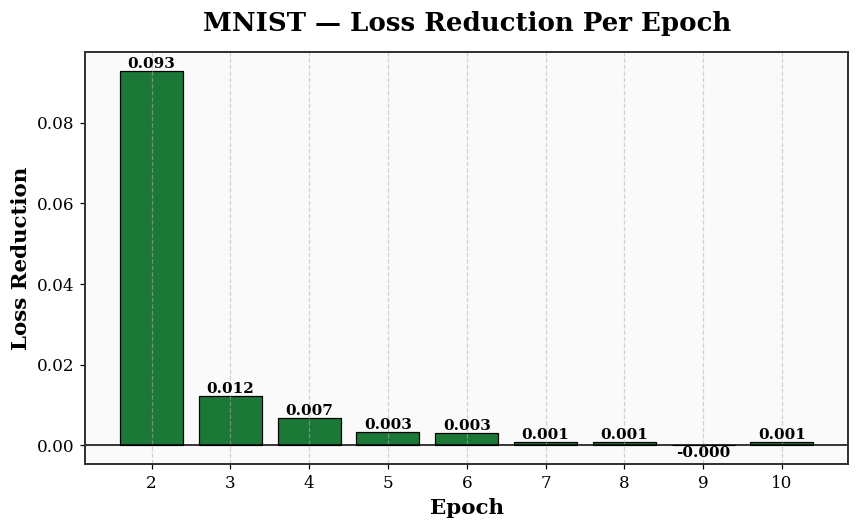

In [ ]:
plot_resnet_training_history(
    mnist_losses,
    mnist_accuracies,
    "MNIST"
)


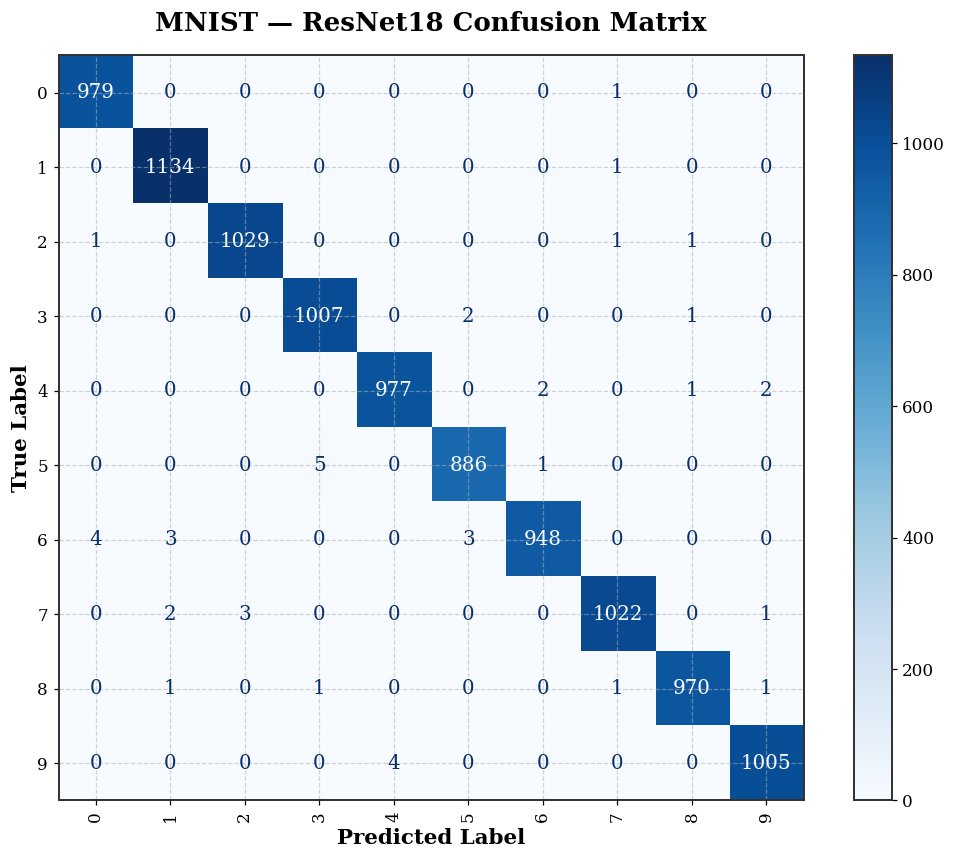

In [ ]:
plot_confusion_matrix(
    mnist_results["confusion_matrix"],
    mnist_class_names,
    "MNIST"
)

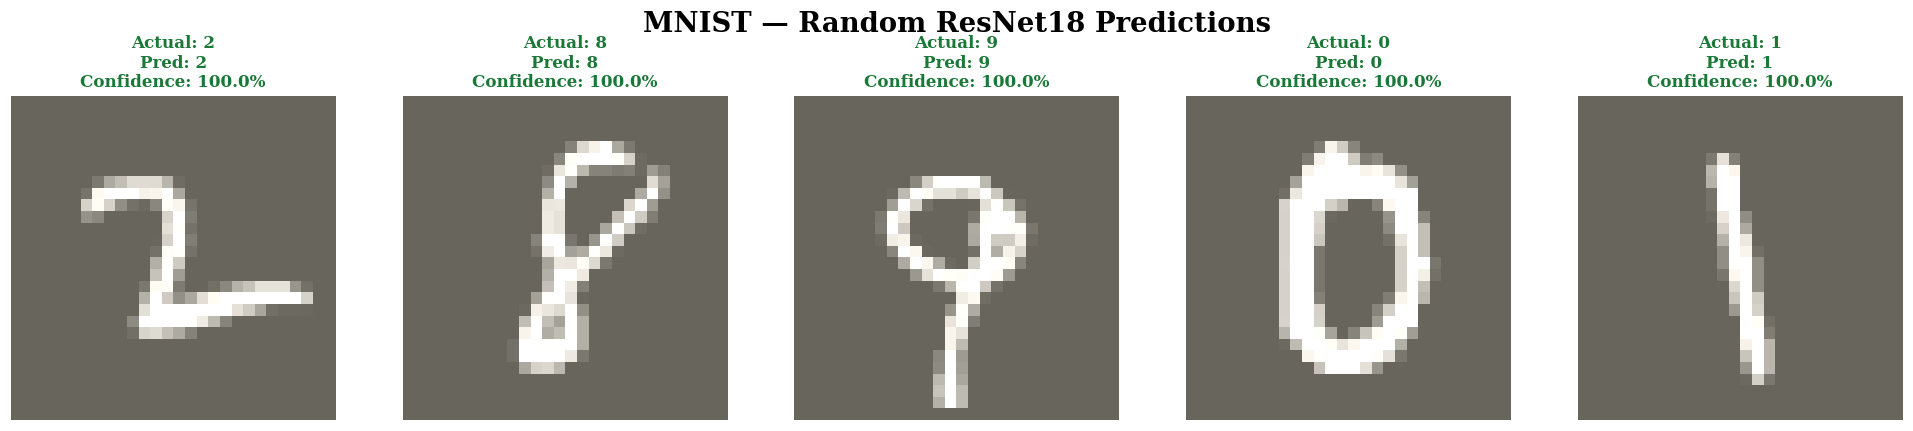

In [ ]:
show_random_predictions(
    mnist_resnet,
    mnist_resnet_test,
    mnist_class_names,
    "MNIST"
)

## Section 14 — ResNet18 on CIFAR-10

### CIFAR-10 — Training

In [ ]:
# ============================================
# Train ResNet18 on CIFAR-10
# ============================================

cifar10_resnet = ResNet18Scratch(num_classes=10)

print("CIFAR-10 ResNet18 parameters:", f"{count_parameters(cifar10_resnet):,}")

cifar10_resnet, cifar10_losses, cifar10_accuracies, cifar10_training_time = train_resnet_model(
    cifar10_resnet,
    cifar10_train_loader
)

print(f"\nCIFAR-10 training time: {cifar10_training_time:.2f} seconds")


CIFAR-10 ResNet18 parameters: 11,173,962
Epoch [1/10] Loss: 1.2819 Accuracy: 53.44%
Epoch [2/10] Loss: 0.8066 Accuracy: 71.55%
Epoch [3/10] Loss: 0.5726 Accuracy: 79.96%
Epoch [4/10] Loss: 0.4045 Accuracy: 85.98%
Epoch [5/10] Loss: 0.2692 Accuracy: 90.64%
Epoch [6/10] Loss: 0.1685 Accuracy: 94.19%
Epoch [7/10] Loss: 0.1034 Accuracy: 96.60%
Epoch [8/10] Loss: 0.0741 Accuracy: 97.62%
Epoch [9/10] Loss: 0.0600 Accuracy: 98.00%
Epoch [10/10] Loss: 0.0389 Accuracy: 98.79%

CIFAR-10 training time: 520.06 seconds


### CIFAR-10 — Evaluation

In [ ]:
# ============================================
# Evaluate CIFAR-10 ResNet18
# ============================================

cifar10_results = evaluate_resnet_model(
    cifar10_resnet,
    cifar10_test_loader
)

print(f"Accuracy : {cifar10_results['accuracy']:.2f}%")
print(f"Precision: {cifar10_results['precision']:.2f}%")
print(f"Recall   : {cifar10_results['recall']:.2f}%")
print(f"F1-score : {cifar10_results['f1']:.2f}%")


Accuracy : 80.53%
Precision: 80.78%
Recall   : 80.53%
F1-score : 80.54%


### CIFAR-10 — Visualizations

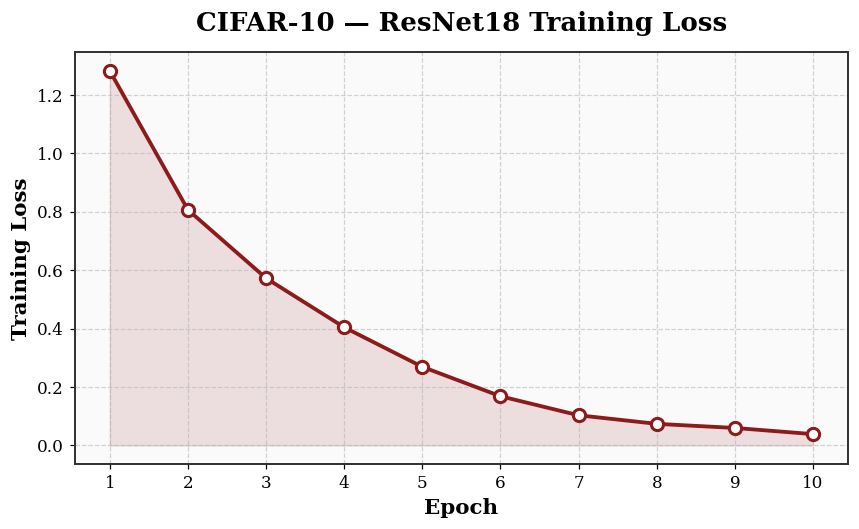

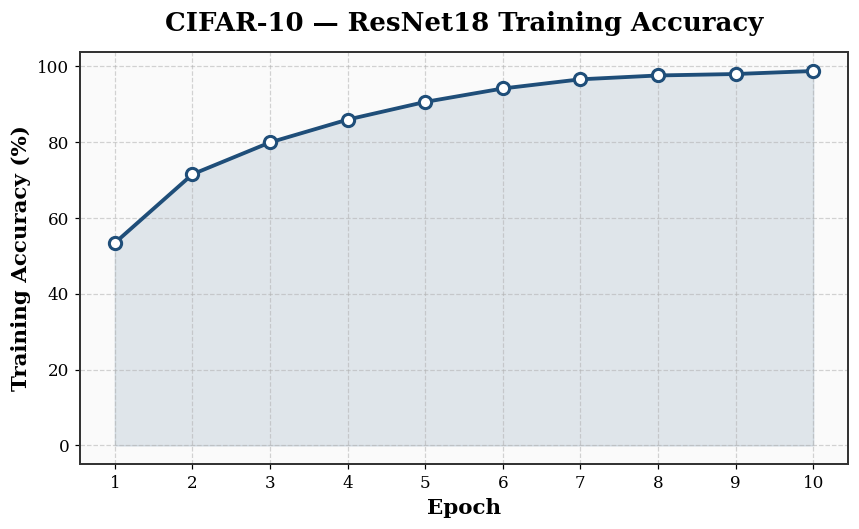

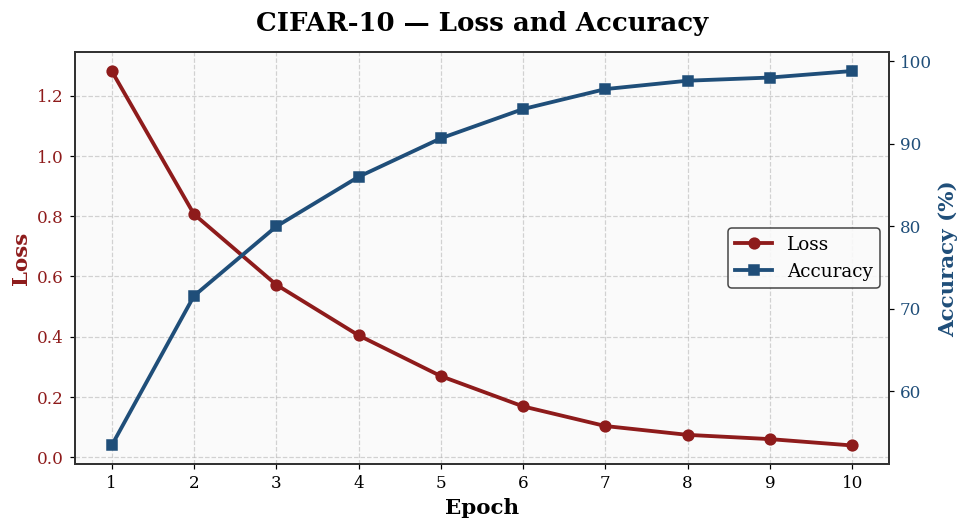

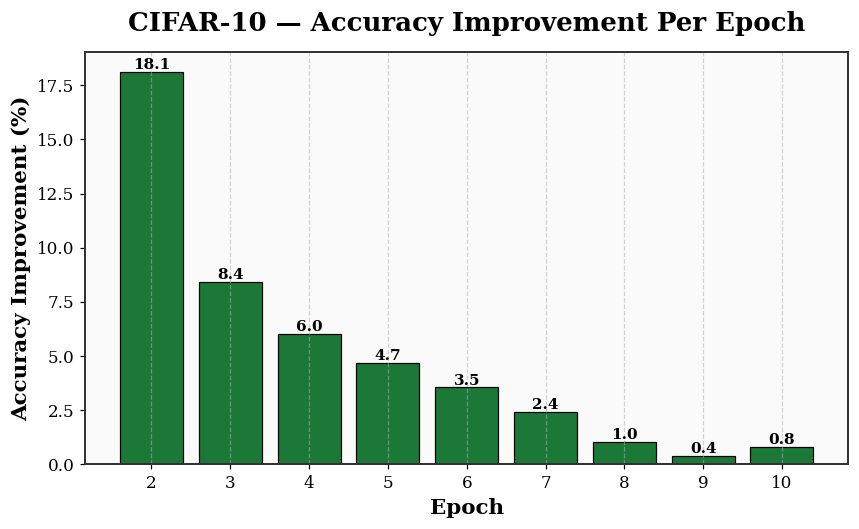

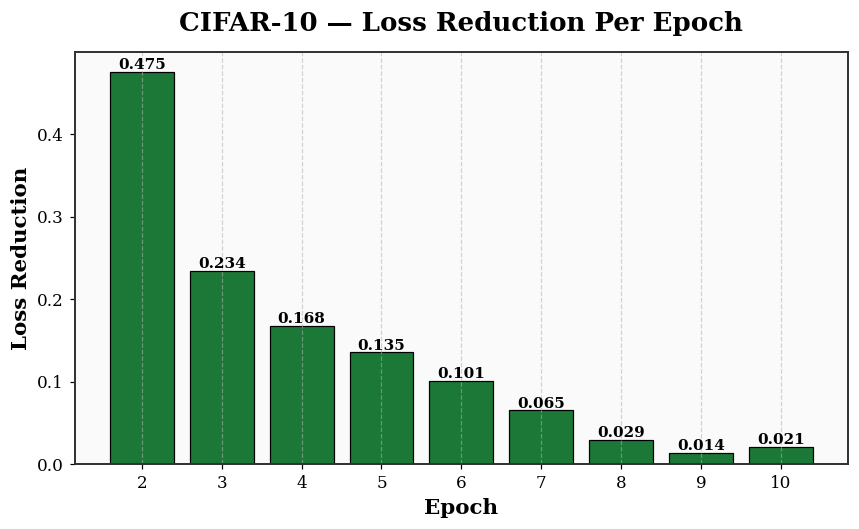

In [ ]:
plot_resnet_training_history(
    cifar10_losses,
    cifar10_accuracies,
    "CIFAR-10"
)

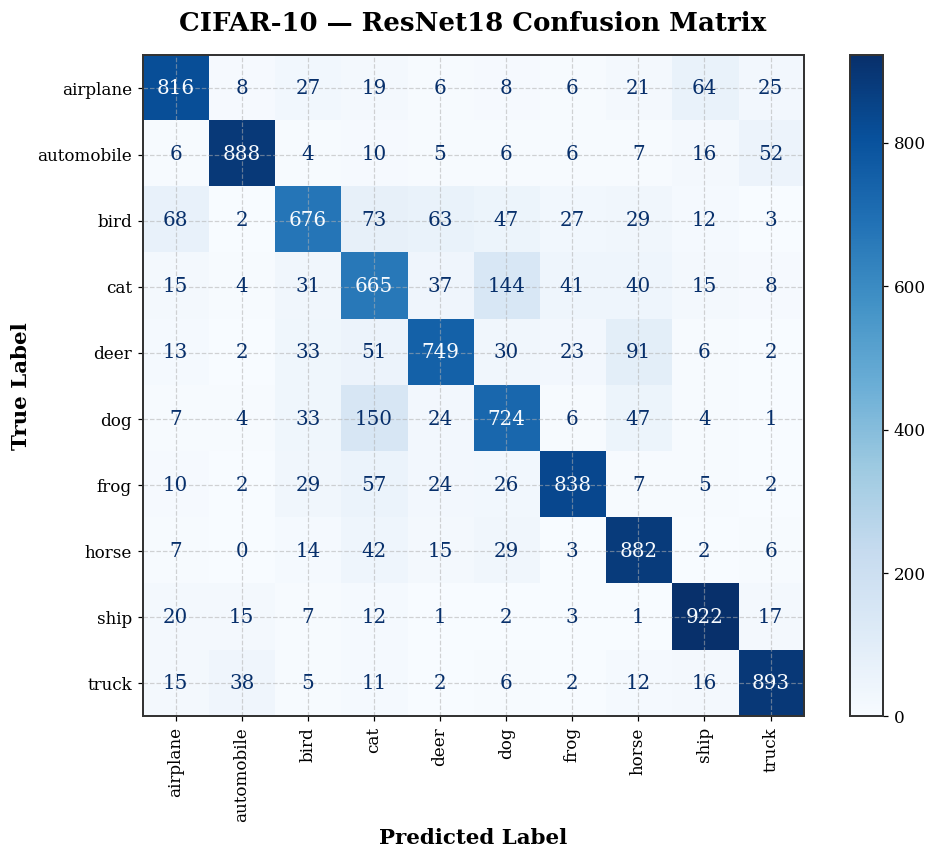

In [ ]:
plot_confusion_matrix(
    cifar10_results["confusion_matrix"],
    cifar10_class_names,
    "CIFAR-10"
)


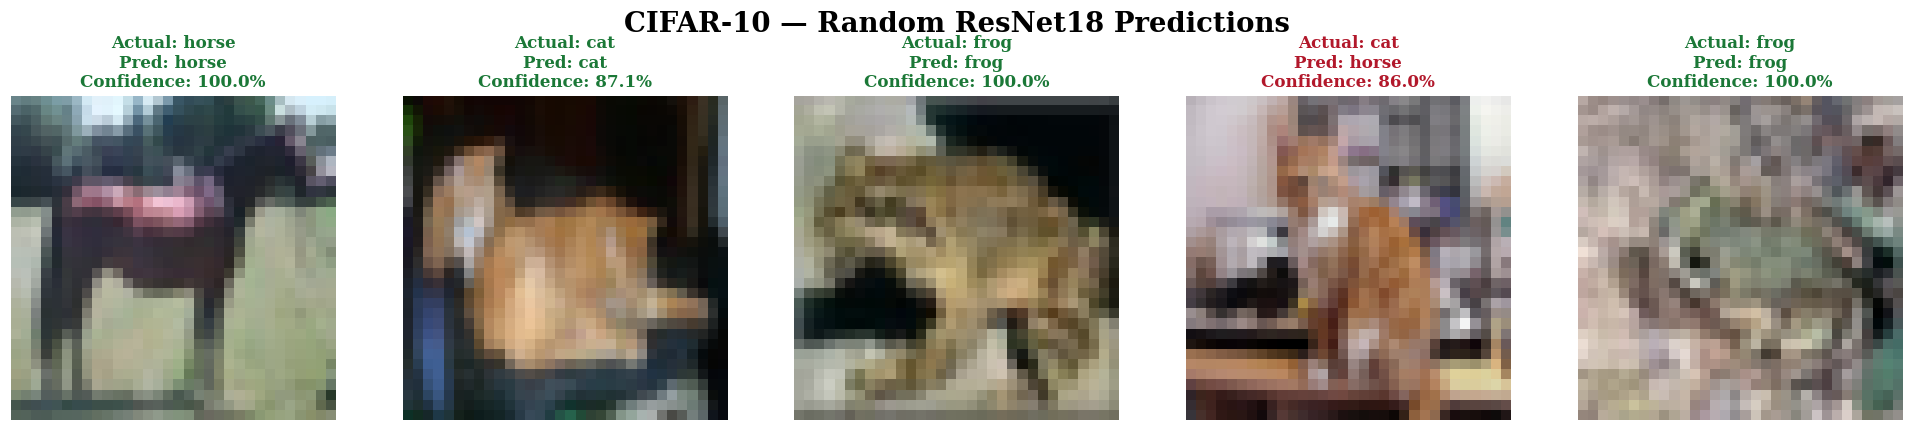

In [ ]:
show_random_predictions(
    cifar10_resnet,
    cifar10_test,
    cifar10_class_names,
    "CIFAR-10"
)

## Section 15 — ResNet18 on CIFAR-100

### CIFAR-100 — Training

In [ ]:
# ============================================
# Train ResNet18 on CIFAR-100
# ============================================

cifar100_resnet = ResNet18Scratch(num_classes=100)

print("CIFAR-100 ResNet18 parameters:", f"{count_parameters(cifar100_resnet):,}")

cifar100_resnet, cifar100_losses, cifar100_accuracies, cifar100_training_time = train_resnet_model(
    cifar100_resnet,
    cifar100_train_loader
)

print(f"\nCIFAR-100 training time: {cifar100_training_time:.2f} seconds")


CIFAR-100 ResNet18 parameters: 11,220,132
Epoch [1/10] Loss: 3.5603 Accuracy: 15.83%
Epoch [2/10] Loss: 2.6761 Accuracy: 31.51%
Epoch [3/10] Loss: 2.1460 Accuracy: 42.75%
Epoch [4/10] Loss: 1.7496 Accuracy: 52.02%
Epoch [5/10] Loss: 1.4185 Accuracy: 60.07%
Epoch [6/10] Loss: 1.0982 Accuracy: 68.74%
Epoch [7/10] Loss: 0.7920 Accuracy: 77.25%
Epoch [8/10] Loss: 0.4909 Accuracy: 86.93%
Epoch [9/10] Loss: 0.2616 Accuracy: 93.94%
Epoch [10/10] Loss: 0.1159 Accuracy: 98.13%

CIFAR-100 training time: 522.14 seconds


### CIFAR-100 — Evaluation

In [ ]:
# ============================================
# Evaluate CIFAR-100 ResNet18
# ============================================

cifar100_results = evaluate_resnet_model(
    cifar100_resnet,
    cifar100_test_loader
)

print(f"Accuracy : {cifar100_results['accuracy']:.2f}%")
print(f"Precision: {cifar100_results['precision']:.2f}%")
print(f"Recall   : {cifar100_results['recall']:.2f}%")
print(f"F1-score : {cifar100_results['f1']:.2f}%")


Accuracy : 52.12%
Precision: 53.59%
Recall   : 52.12%
F1-score : 52.01%


### CIFAR-100 — Visualizations

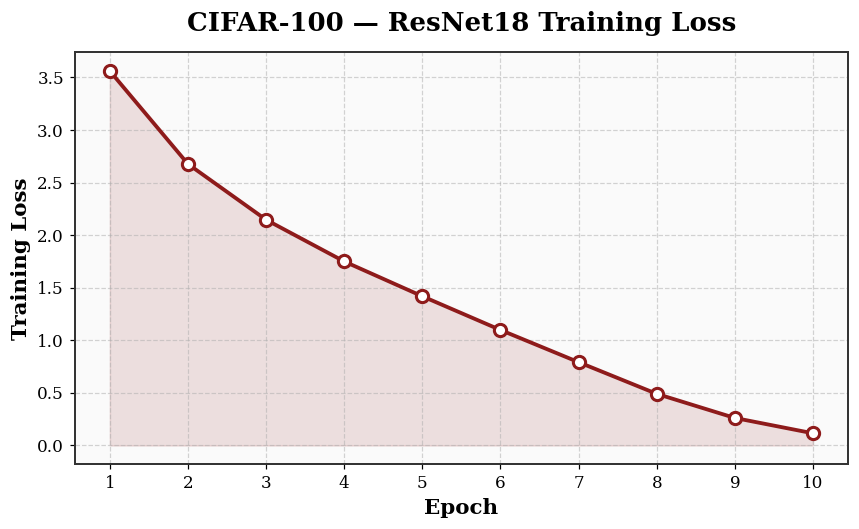

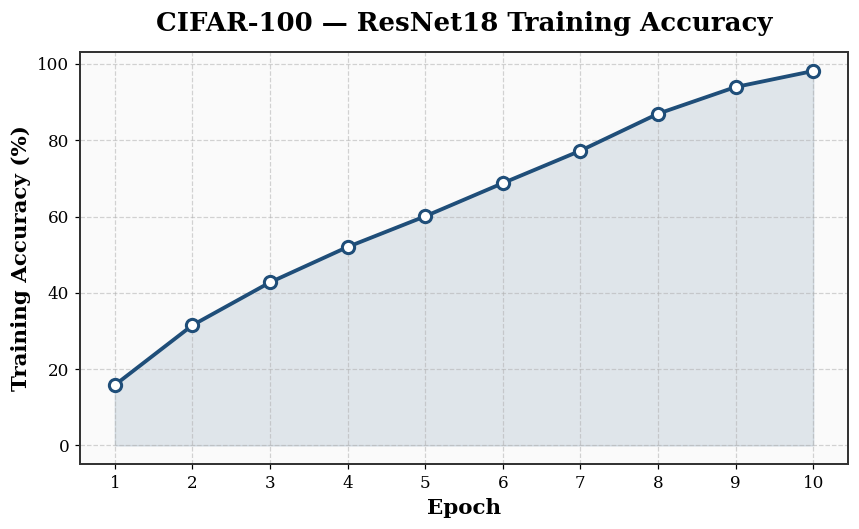

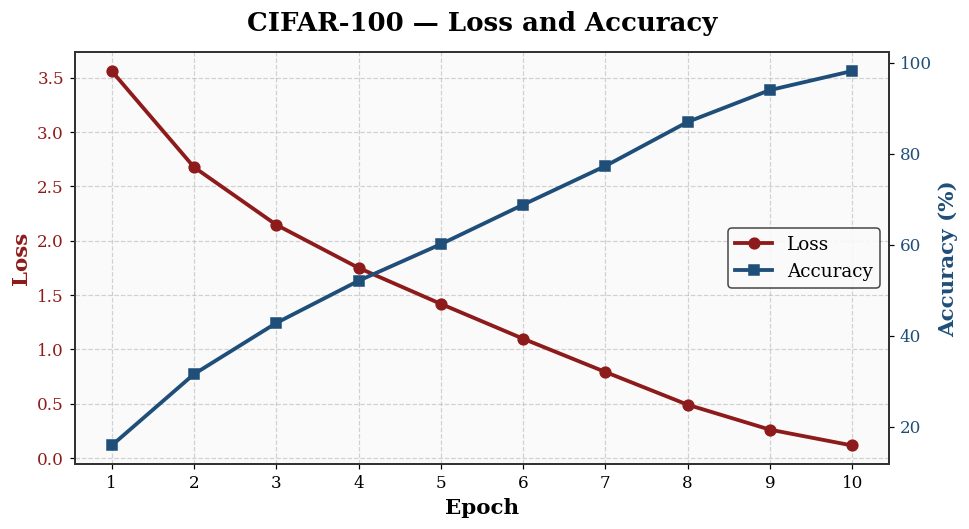

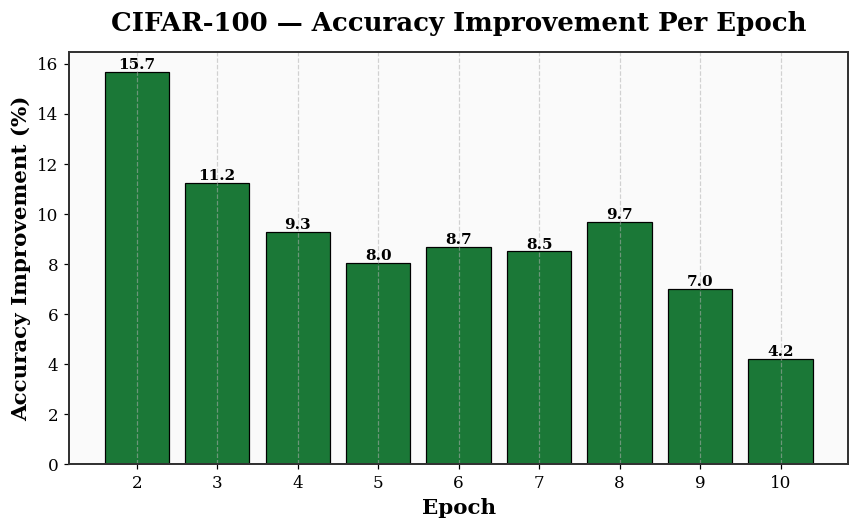

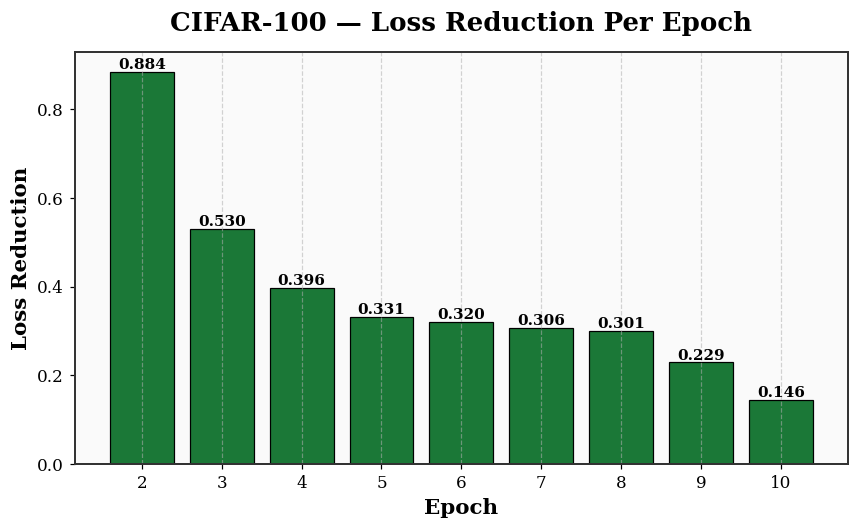

In [ ]:
plot_resnet_training_history(
    cifar100_losses,
    cifar100_accuracies,
    "CIFAR-100"
)

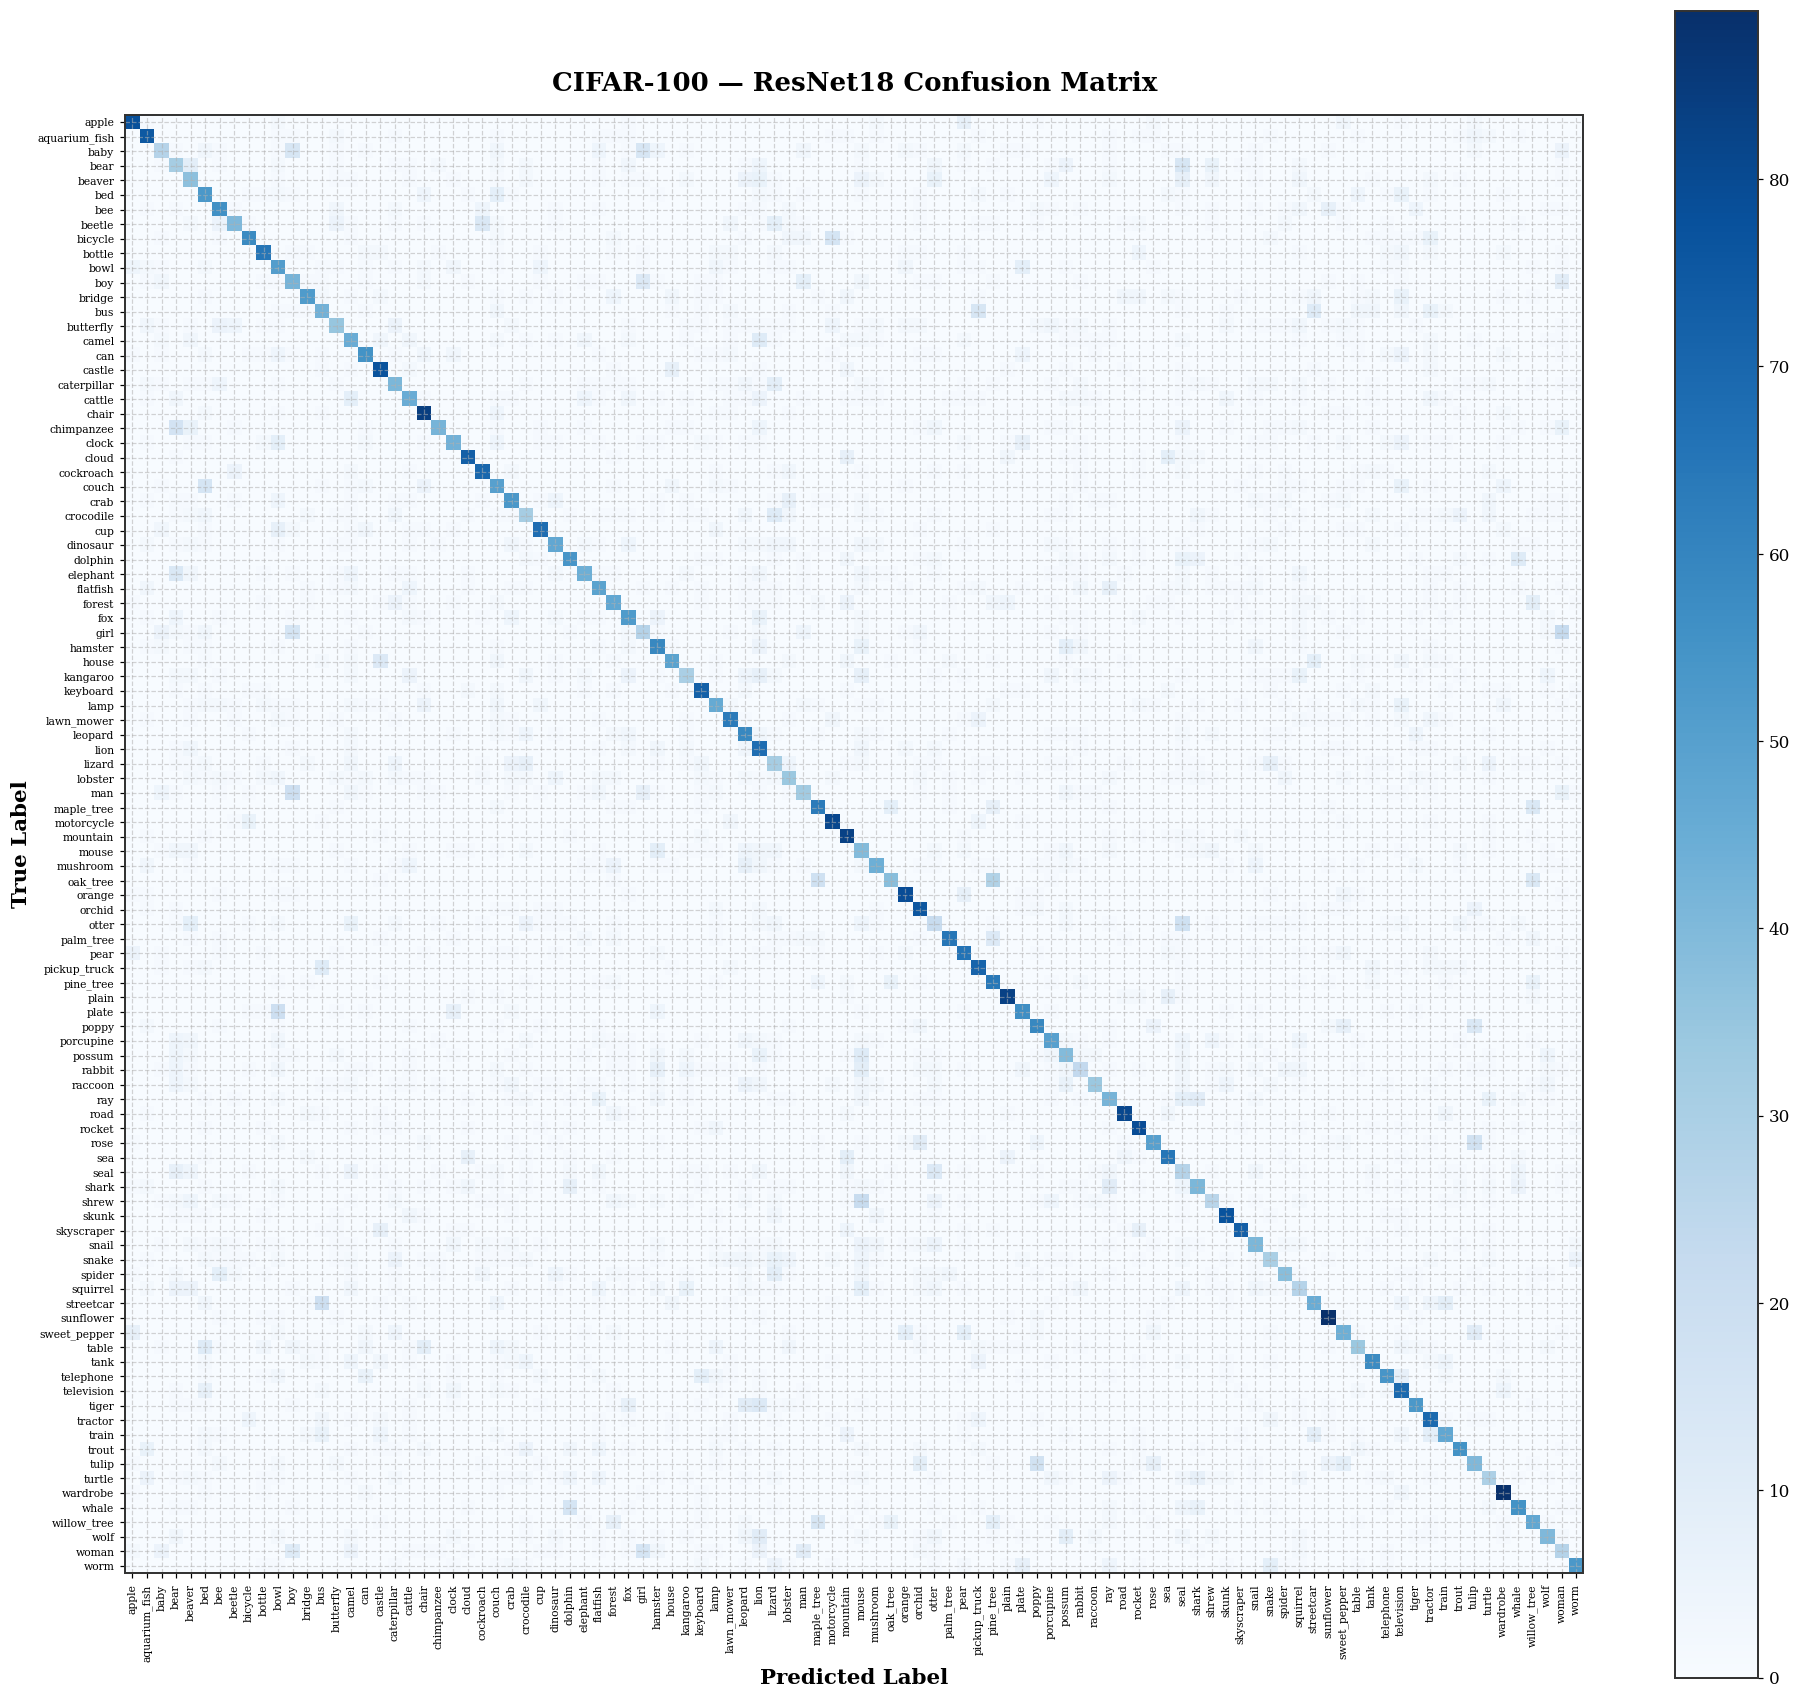

In [ ]:
plot_confusion_matrix(
    cifar100_results["confusion_matrix"],
    cifar100_class_names,
    "CIFAR-100"
)

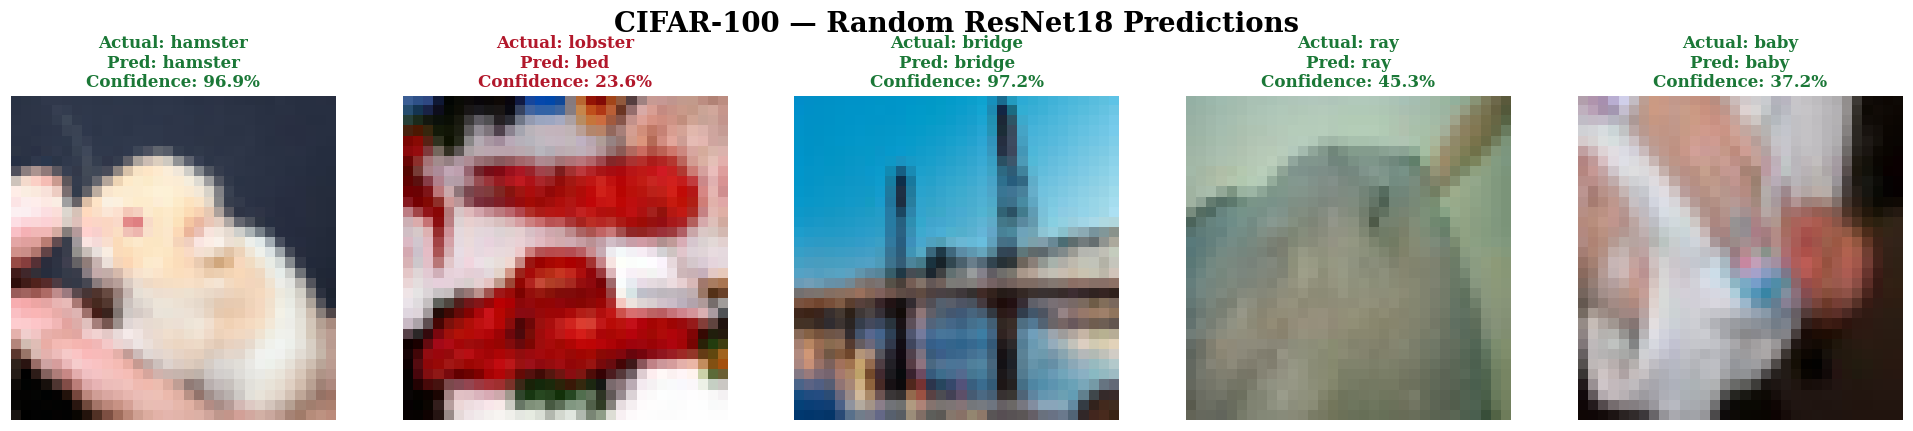

In [ ]:
show_random_predictions(
    cifar100_resnet,
    cifar100_test,
    cifar100_class_names,
    "CIFAR-100"
)


## Section 16 — Q3 Results Table

In [ ]:
# ============================================
# Q3 comparison table
# ============================================

q3_results = {
    "Dataset": ["MNIST", "CIFAR-10", "CIFAR-100"],
    "Accuracy": [
        mnist_results["accuracy"],
        cifar10_results["accuracy"],
        cifar100_results["accuracy"]
    ],
    "Precision": [
        mnist_results["precision"],
        cifar10_results["precision"],
        cifar100_results["precision"]
    ],
    "Recall": [
        mnist_results["recall"],
        cifar10_results["recall"],
        cifar100_results["recall"]
    ],
    "F1-score": [
        mnist_results["f1"],
        cifar10_results["f1"],
        cifar100_results["f1"]
    ],
    "Training Time (s)": [
        mnist_training_time,
        cifar10_training_time,
        cifar100_training_time
    ]
}

import pandas as pd

q3_results_df = pd.DataFrame(q3_results)

display(
    q3_results_df.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1-score": "{:.2f}%",
        "Training Time (s)": "{:.2f}"
    })
)


,Dataset,Accuracy,Precision,Recall,F1-score,Training Time (s)
0,MNIST,99.57%,99.57%,99.57%,99.57%,572.10
1,CIFAR-10,80.53%,80.78%,80.53%,80.54%,520.06
2,CIFAR-100,52.12%,53.59%,52.12%,52.01%,522.14


## Section 17 — Q3 Performance Comparison

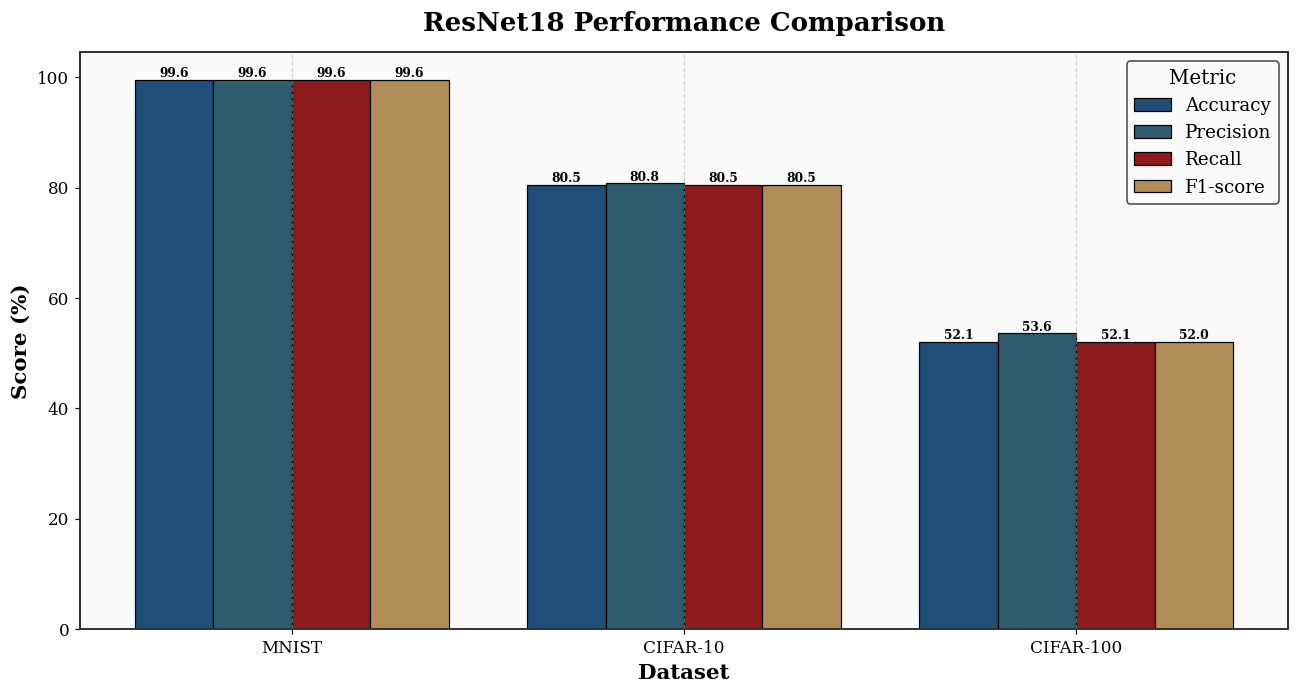

In [ ]:
# ============================================
# Q3 comparison graph
# ============================================

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

x = np.arange(len(q3_results_df["Dataset"]))
width = 0.2

plt.figure(figsize=(12, 6.5))

for i, metric in enumerate(metrics):
    bars = plt.bar(
        x + (i - 1.5) * width,
        q3_results_df[metric],
        width,
        label=metric,
        color=comparison_colors[i],
        edgecolor="black",
        linewidth=0.8,
    )

    for bar, value in zip(bars, q3_results_df[metric]):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.1f}", ha="center", va="bottom",
            fontsize=8, fontweight="bold",
        )

plt.xticks(x, q3_results_df["Dataset"])
plt.ylabel("Score (%)")
plt.xlabel("Dataset")
plt.title("ResNet18 Performance Comparison", fontsize=17, fontweight="bold", pad=14)
plt.legend(title="Metric")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Section 18 — Residual Connection / Depth Experiment

### Residual Depth — Model Definition

In [ ]:
# ============================================
# Residual-depth experiment model
# ============================================

class ResNetDepthExperiment(nn.Module):
    def __init__(self, num_classes=10, blocks_per_stage=(1, 1, 1, 1)):
        super(ResNetDepthExperiment, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(
            64, blocks_per_stage[0], stride=1
        )
        self.layer2 = self._make_layer(
            128, blocks_per_stage[1], stride=2
        )
        self.layer3 = self._make_layer(
            256, blocks_per_stage[2], stride=2
        )
        self.layer4 = self._make_layer(
            512, blocks_per_stage[3], stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = [
            BasicBlock(self.in_channels, out_channels, stride)
        ]

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(self.in_channels, out_channels, 1)
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# Use a smaller subset for the architecture experiment
experiment_size = 10000

experiment_indices = list(range(experiment_size))

cifar10_experiment_dataset = Subset(
    cifar10_train,
    experiment_indices
)

cifar10_experiment_loader = DataLoader(
    cifar10_experiment_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Experiment dataset size:", len(cifar10_experiment_dataset))


Experiment dataset size: 10000


### Residual Depth — Training Function

In [ ]:
# ============================================
# Train depth experiment
# ============================================

def run_depth_experiment(block_config, epochs=EPOCHS):
    model = ResNetDepthExperiment(
        num_classes=10,
        blocks_per_stage=block_config
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE
    )

    losses = []
    accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in cifar10_experiment_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

        losses.append(running_loss / total)
        accuracies.append(100 * correct / total)

    training_time = time.time() - start_time

    test_results = evaluate_resnet_model(
        model,
        cifar10_test_loader
    )

    return {
        "blocks": sum(block_config),
        "configuration": str(block_config),
        "accuracy": test_results["accuracy"],
        "precision": test_results["precision"],
        "recall": test_results["recall"],
        "f1": test_results["f1"],
        "training_time": training_time,
        "parameters": count_parameters(model),
        "losses": losses,
        "accuracies": accuracies
    }


### Residual Depth — Running the Experiment

In [ ]:
# ============================================
# Run residual-depth experiment
# ============================================

depth_configs = [
    (1, 1, 1, 1),
    (1, 1, 2, 2),
    (2, 2, 2, 2)
]

depth_results = []

for config in depth_configs:
    print("\nRunning configuration:", config)

    result = run_depth_experiment(config)
    depth_results.append(result)

    print(
        f"Accuracy: {result['accuracy']:.2f}% | "
        f"F1: {result['f1']:.2f}% | "
        f"Time: {result['training_time']:.2f}s | "
        f"Parameters: {result['parameters']:,}"
    )

depth_results_df = pd.DataFrame([
    {
        "Residual Blocks": r["blocks"],
        "Configuration": r["configuration"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1-score": r["f1"],
        "Training Time (s)": r["training_time"],
        "Parameters": r["parameters"]
    }
    for r in depth_results
])

display(
    depth_results_df.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1-score": "{:.2f}%",
        "Training Time (s)": "{:.2f}",
        "Parameters": "{:,}"
    })
)



Running configuration: (1, 1, 1, 1)
Accuracy: 49.98% | F1: 50.86% | Time: 62.71s | Parameters: 4,903,242

Running configuration: (1, 1, 2, 2)
Accuracy: 58.30% | F1: 57.51% | Time: 83.23s | Parameters: 10,804,554

Running configuration: (2, 2, 2, 2)
Accuracy: 61.17% | F1: 60.87% | Time: 104.68s | Parameters: 11,173,962


,Residual Blocks,Configuration,Accuracy,Precision,Recall,F1-score,Training Time (s),Parameters
0,4,"(1, 1, 1, 1)",49.98%,61.06%,49.98%,50.86%,62.71,"4,903,242"
1,6,"(1, 1, 2, 2)",58.30%,58.22%,58.30%,57.51%,83.23,"10,804,554"
2,8,"(2, 2, 2, 2)",61.17%,62.73%,61.17%,60.87%,104.68,"11,173,962"


### Residual Depth — Accuracy vs Depth

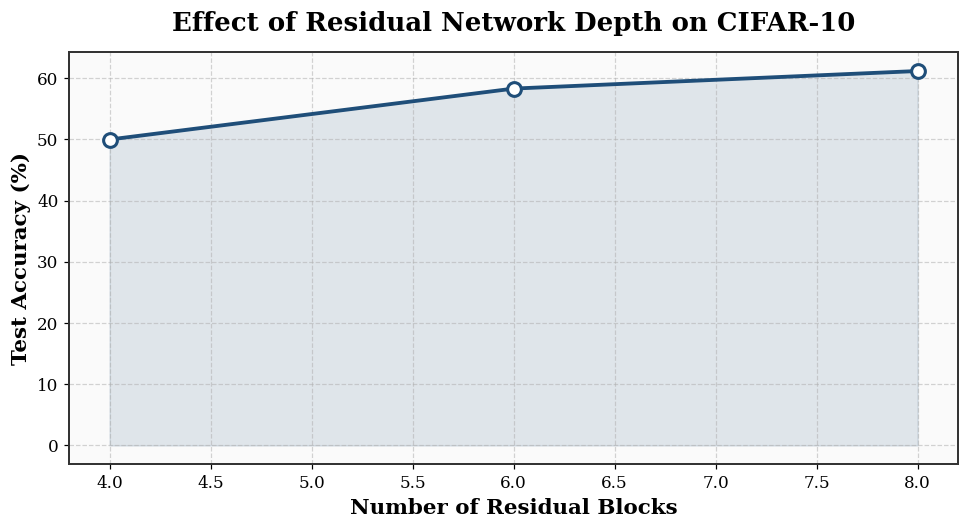

In [ ]:
# ============================================
# Residual depth experiment graph
# ============================================

plt.figure(figsize=(9, 5))

plt.plot(
    depth_results_df["Residual Blocks"],
    depth_results_df["Accuracy"],
    marker="o", linewidth=2.5, markersize=9,
    color=PALETTE["accuracy"], markerfacecolor="white",
    markeredgewidth=2, markeredgecolor=PALETTE["accuracy"],
)
plt.fill_between(
    depth_results_df["Residual Blocks"],
    depth_results_df["Accuracy"],
    alpha=0.12, color=PALETTE["accuracy"],
)

plt.xlabel("Number of Residual Blocks")
plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Residual Network Depth on CIFAR-10", pad=14)
plt.grid(True)
plt.tight_layout()
plt.show()


### Residual Depth — Training Stability


In [ ]:
# This graph compares the training loss curves for the tested residual depths.
# A smoother and consistently decreasing loss indicates more stable optimisation, while large oscillations
# or stalled loss reduction can indicate training instability.


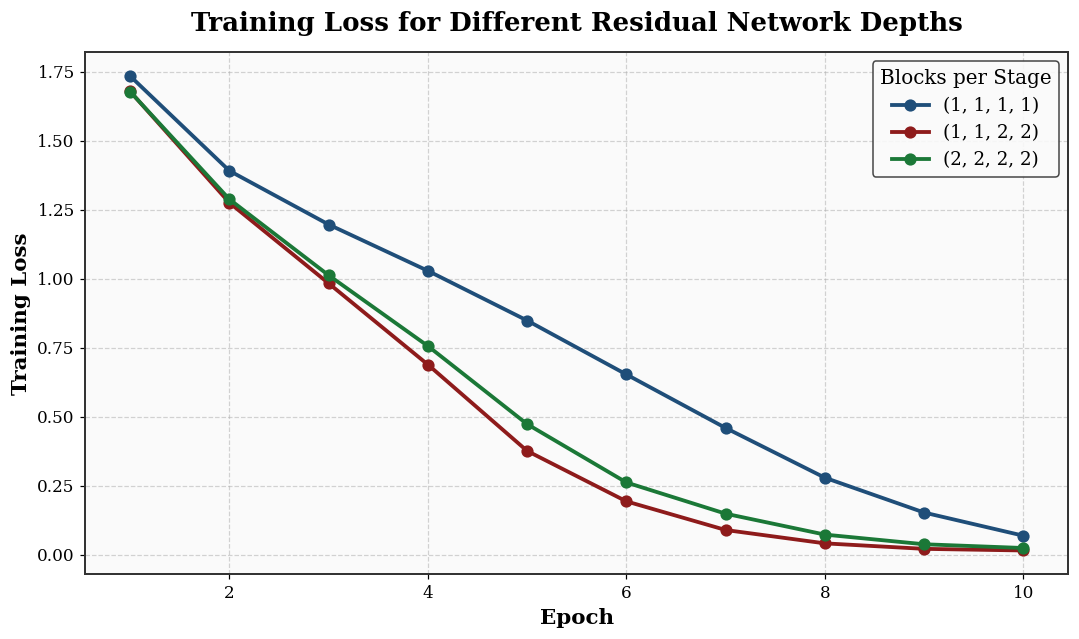

In [ ]:
# ============================================
# Training stability comparison
# ============================================

plt.figure(figsize=(10, 6))

stability_colors = ["#1F4E79", "#8E1B1B", "#1B7837", "#B08D57", "#6A3D9A"]

for i, result in enumerate(depth_results):
    plt.plot(
        range(1, len(result["losses"]) + 1),
        result["losses"],
        marker="o", linewidth=2.5, markersize=7,
        color=stability_colors[i % len(stability_colors)],
        label=result["configuration"],
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Residual Network Depths", pad=14)
plt.legend(title="Blocks per Stage")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
q3_results_df.round(2)

,Dataset,Accuracy,Precision,Recall,F1-score,Training Time (s)
0,MNIST,99.57,99.57,99.57,99.57,572.10
1,CIFAR-10,80.53,80.78,80.53,80.54,520.06
2,CIFAR-100,52.12,53.59,52.12,52.01,522.14


In [ ]:
depth_results_df.round(2)

,Residual Blocks,Configuration,Accuracy,Precision,Recall,F1-score,Training Time (s),Parameters
0,4,"(1, 1, 1, 1)",49.98,61.06,49.98,50.86,62.71,4903242
1,6,"(1, 1, 2, 2)",58.30,58.22,58.30,57.51,83.23,10804554
2,8,"(2, 2, 2, 2)",61.17,62.73,61.17,60.87,104.68,11173962


## Section 19 — Q3 Analysis

ResNet18 achieved its best performance on MNIST, with 99.57% accuracy, precision, recall and F1-score. On CIFAR-10, the model achieved 80.53% accuracy, while CIFAR-100 was more difficult, achieving 52.12% accuracy. This is expected because CIFAR-100 has more classes and more complex images.

The residual-depth experiment shows that increasing the number of residual blocks improved performance. Accuracy increased from 49.98% with 4 blocks to 58.30% with 6 blocks and 61.17% with 8 blocks. However, deeper models required more parameters and longer training time. This demonstrates that residual connections allow deeper networks to learn more effectively while maintaining stable training.

## Section 20 — Q3 Conclusion

ResNet18 performed best on MNIST and showed strong performance on CIFAR-10 and CIFAR-100. Increasing residual depth improved predictive performance, with the 8-block configuration achieving the highest accuracy of 61.17%. The results demonstrate the benefit of residual connections for learning deeper CNN architectures, although deeper models increase computational cost.